In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler

In [7]:
df = sns.load_dataset("titanic")
print("Dataset loaded successfully!")

Dataset loaded successfully!


In [8]:
print(df)
df.head()
df.tail()
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

     survived  pclass     sex   age  sibsp  parch     fare embarked   class  \
0           0       3    male  22.0      1      0   7.2500        S   Third   
1           1       1  female  38.0      1      0  71.2833        C   First   
2           1       3  female  26.0      0      0   7.9250        S   Third   
3           1       1  female  35.0      1      0  53.1000        S   First   
4           0       3    male  35.0      0      0   8.0500        S   Third   
..        ...     ...     ...   ...    ...    ...      ...      ...     ...   
886         0       2    male  27.0      0      0  13.0000        S  Second   
887         1       1  female  19.0      0      0  30.0000        S   First   
888         0       3  female   NaN      1      2  23.4500        S   Third   
889         1       1    male  26.0      0      0  30.0000        C   First   
890         0       3    male  32.0      0      0   7.7500        Q   Third   

       who  adult_male deck  embark_town alive  alo

In [9]:
missing_values = df.isnull().sum()
print(missing_values)
print("Number of duplicate records:", df.duplicated().sum())


survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64
Number of duplicate records: 107


In [10]:
df = df.drop_duplicates()
print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (784, 15)


In [11]:
columns_to_remove = [
    "alive",
    "class",
    "who",
    "adult_male",
    "deck",
    "embark_town",
    "alone"
]

df = df.drop(columns=columns_to_remove)

print("Remaining columns:")
print(df.columns.tolist())

Remaining columns:
['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']


In [12]:
print(df.isnull().sum())

survived      0
pclass        0
sex           0
age         106
sibsp         0
parch         0
fare          0
embarked      2
dtype: int64


In [13]:
median_age = df["age"].median()
print("Median age:", median_age)

Median age: 28.25


In [14]:
df["age"] = df["age"].fillna(median_age)

print("Missing values in age:", df["age"].isnull().sum())

Missing values in age: 0


In [15]:
mode_embarked = df["embarked"].mode()[0]

print("Most frequent embarkation point:", mode_embarked)

df["embarked"] = df["embarked"].fillna(mode_embarked)

print("Missing values in embarked:", df["embarked"].isnull().sum())

Most frequent embarkation point: S
Missing values in embarked: 0


In [16]:
print("Missing values after treatment:")
print(df.isnull().sum())


Missing values after treatment:
survived    0
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
dtype: int64


In [17]:
print("Unique values in sex:")
print(df["sex"].unique())

print("\nUnique values in embarked:")
print(df["embarked"].unique())

Unique values in sex:
['male' 'female']

Unique values in embarked:
['S' 'C' 'Q']


In [18]:
le = LabelEncoder()

df["sex"] = le.fit_transform(df["sex"])

print(df[["sex"]].head())

   sex
0    1
1    0
2    0
3    0
4    1


In [19]:
df = pd.get_dummies(df, columns=["embarked"], drop_first=True)

df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked_Q,embarked_S
0,0,3,1,22.0,1,0,7.2500,False,True
1,1,1,0,38.0,1,0,71.2833,False,False
2,1,3,0,26.0,0,0,7.9250,False,True
3,1,1,0,35.0,1,0,53.1000,False,True
4,0,3,1,35.0,0,0,8.0500,False,True


In [20]:
features_to_scale = ["age", "sibsp", "parch", "fare"]

print("Features selected for scaling:")
print(features_to_scale)

Features selected for scaling:
['age', 'sibsp', 'parch', 'fare']


In [21]:
scaler = StandardScaler()

df[features_to_scale] = scaler.fit_transform(df[features_to_scale])

print("Feature scaling completed.")

Feature scaling completed.


In [22]:
print("Mean after scaling:")
print(df[features_to_scale].mean())

print("\nStandard deviation after scaling:")
print(df[features_to_scale].std())

Mean after scaling:
age      1.540718e-16
sibsp   -4.984675e-17
parch    2.039185e-17
fare    -6.910572e-17
dtype: float64

Standard deviation after scaling:
age      1.000638
sibsp    1.000638
parch    1.000638
fare     1.000638
dtype: float64


In [23]:
print("\nFinal dataset:")
display(df.head(10))


Final dataset:


,survived,pclass,sex,age,sibsp,parch,fare,embarked_Q,embarked_S
0,0,3,1,-0.557360,0.484009,-0.497157,-0.526825,False,True
1,1,1,0,0.608298,0.484009,-0.497157,0.701587,False,False
2,1,3,0,-0.265945,-0.530599,-0.497157,-0.513876,False,True
3,1,1,0,0.389737,0.484009,-0.497157,0.352760,False,True
4,0,3,1,0.389737,-0.530599,-0.497157,-0.511478,False,True
5,0,3,1,-0.102025,-0.530599,-0.497157,-0.503645,True,False
6,0,1,1,1.773955,-0.530599,-0.497157,0.329020,False,True
7,0,3,1,-2.014431,2.513226,0.698460,-0.261607,False,True
8,1,3,0,-0.193092,-0.530599,1.894076,-0.452328,False,True
9,1,2,0,-1.140188,0.484009,-0.497157,-0.089032,False,False


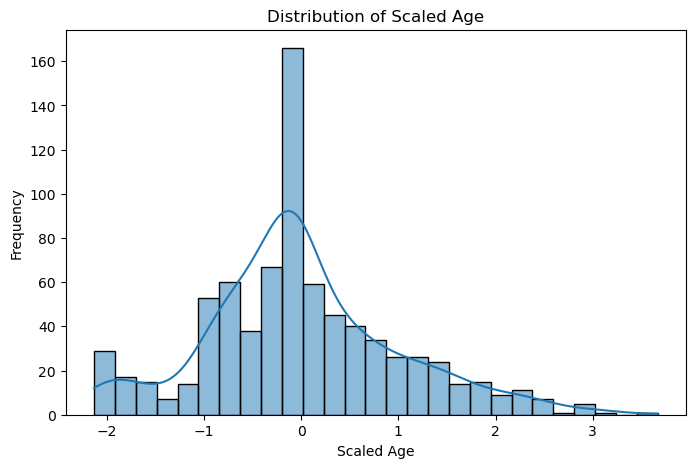

In [24]:
plt.figure(figsize=(8, 5))

sns.histplot(df["age"], kde=True)

plt.title("Distribution of Scaled Age")
plt.xlabel("Scaled Age")
plt.ylabel("Frequency")

plt.show()